# Hyperglyph Generator — music-synesthesia design exploration

Generates a batch of unique, randomized GlyphViz hyperglyphs (multi-level branching node hierarchies): you pick `branch_levels` and `max_nodes`, this notebook picks geometries, topologies, scale, position, rotation, and colour (including gradients) for every level, using colour-theory palettes and geometry "families" so each result reads as one coherent design rather than noise.

Each design writes:
- `output/<design_id>_gv_node.csv` / `_gv_tag.csv` — open directly in GlyphViz
- `output/<design_id>_recipe.json` — open in **Tools > Glyph Composer** to hand-tweak

and one row lands in `ratings.csv` with blank `rating`/`categories`/`notes` columns.

**The loop:** generate a batch → open a few in GlyphViz → score the ones worth keeping in `ratings.csv` (via the `rate_design()` helper below, or by hand in Excel) → generate the next batch. Once >=3 designs are rated >=7, new batches automatically spend part of their budget mutating your top-rated designs (small jitter to scale/rotation/colour/counts) instead of pure random exploration — see `explore_ratio` below.

In [1]:
import sys
from pathlib import Path

LAB_DIR = Path.cwd() if (Path.cwd() / "hyperglyph_generator.py").exists() else Path("hyperglyph_lab")
sys.path.insert(0, str(LAB_DIR))

import pandas as pd
from hyperglyph_generator import generate_batch, RatingsStore

OUTPUT_DIR = LAB_DIR / "output"
RATINGS_CSV = LAB_DIR / "ratings.csv"
ratings = RatingsStore(RATINGS_CSV)

## Parameters — edit these and re-run the next cell

In [2]:
BRANCH_LEVELS = 8      # including the trunk, e.g. 5 = trunk + 4 branching levels
MAX_NODES = 5000       # upper bound (a cap, not a target) on total nodes per hyperglyph
COUNT = 10             # how many unique hyperglyphs to generate this batch
NAME_PREFIX = "hyperglyph"
SEED = None            # set an int for a reproducible batch
EXPLORE_RATIO = None   # None = auto (100% until >=3 designs rated >=7, then 40% explore / 60% exploit)
IDLE_MOTION = True     # slow counter-rotating spin per level, so it reads as alive even without audio Channels

In [4]:
rows = generate_batch(
    branch_levels=BRANCH_LEVELS,
    max_nodes=MAX_NODES,
    count=COUNT,
    output_dir=OUTPUT_DIR,
    name_prefix=NAME_PREFIX,
    explore_ratio=EXPLORE_RATIO,
    seed=SEED,
    idle_motion=IDLE_MOTION,
    ratings_path=RATINGS_CSV,
)
df = pd.DataFrame(rows)
df[["design_id", "actual_node_count", "generation_mode", "parent_design_id", "geometry_family", "palette_scheme", "translucent"]]

,design_id,actual_node_count,generation_mode,parent_design_id,geometry_family,palette_scheme,translucent
0,hyperglyph_000_gv_node20260701065854,1939,random,,mixed,complementary,False
1,hyperglyph_001_gv_node20260701065854,4809,random,,round,analogous,True
2,hyperglyph_002_gv_node20260701065855,3379,random,,round,triadic,False
3,hyperglyph_003_gv_node20260701065855,4089,random,,platonic,complementary,False
4,hyperglyph_004_gv_node20260701065855,4999,random,,wire_only,rainbow,False
5,hyperglyph_005_gv_node20260701065855,4631,random,,particles,split_complementary,False
6,hyperglyph_006_gv_node20260701065856,1119,random,,spiky,rainbow,False
7,hyperglyph_007_gv_node20260701065856,4253,random,,particles,split_complementary,False
8,hyperglyph_008_gv_node20260701065856,4266,random,,mixed,split_complementary,True
9,hyperglyph_009_gv_node20260701065856,4181,random,,platonic,rainbow,False


## Quick visual peek (optional — needs `matplotlib`)

This is a rough node-position/colour scatter, **not** an accurate render (it ignores topology surface shape, geometry, and scale falloff) — it's just a fast way to skim a batch before deciding which ones are worth opening for real in the GlyphViz viewer. If `matplotlib` isn't installed in this kernel's environment, this cell just explains that and skips.

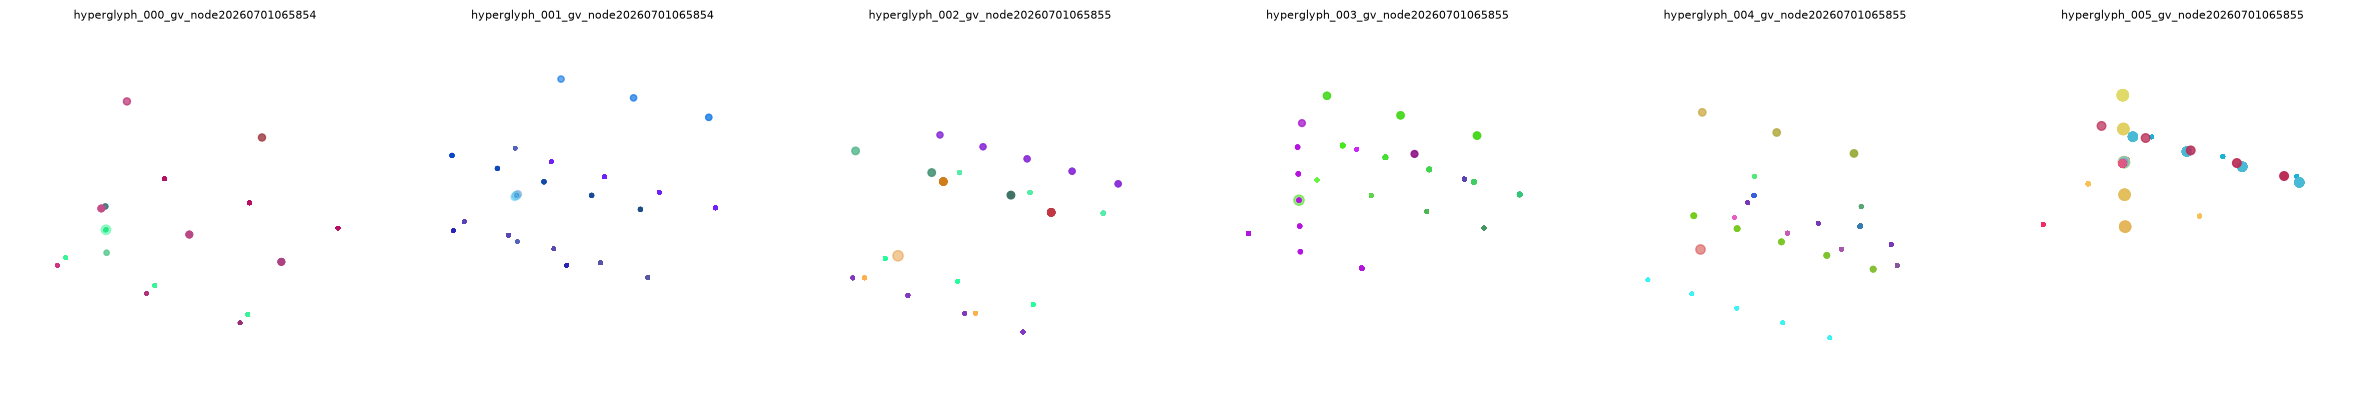

In [5]:
try:
    import matplotlib.pyplot as plt
    from glyphviz_core.csv_reader import load_node_csv

    n_preview = min(len(rows), 6)
    fig = plt.figure(figsize=(4 * n_preview, 4))
    for i, row in enumerate(rows[:n_preview]):
        nodes = load_node_csv(row["node_csv"])
        ax = fig.add_subplot(1, n_preview, i + 1, projection="3d")
        xs = [n.translate_x for n in nodes]
        ys = [n.translate_y for n in nodes]
        zs = [n.translate_z for n in nodes]
        colors = [(n.color_r / 255, n.color_g / 255, n.color_b / 255) for n in nodes]
        sizes = [max(4, 40 * max(n.scale_x, n.scale_y, n.scale_z)) for n in nodes]
        ax.scatter(xs, ys, zs, c=colors, s=sizes)
        ax.set_title(row["design_id"], fontsize=8)
        ax.set_axis_off()
    plt.tight_layout()
    plt.show()
except ImportError:
    print("matplotlib isn't installed in this kernel's environment — skipping the quick preview.\n"
          "Install it (pip/conda install matplotlib) for a fast skim, or just open the node CSVs\n"
          "directly in GlyphViz, which is the accurate way to judge these anyway.")

## Rating workflow

Open the designs worth a closer look in GlyphViz (or the Glyph Composer, via the paired `_recipe.json`), then score them here. `rating` is 1-10; `categories` is free-text aesthetic tags (comma-separated) — there's no fixed vocabulary, use whatever words actually describe what you're seeing (`blobby`, `sharp`, `menacing`, `playful`, `fragile`, ...). These accumulate in `ratings.csv` across every batch you ever run.

In [ ]:
# Example — edit design_id/rating/categories and run:
# ratings.set_rating("hyperglyph_003_gv_node20260701153045", rating=8, categories="blobby,smooth", notes="nice slow spiral droop")

## Leaderboard — top-rated designs so far

In [ ]:
all_df = pd.DataFrame(ratings.load())
if not all_df.empty:
    rated = all_df[all_df["rating"] != ""].copy()
    rated["rating"] = pd.to_numeric(rated["rating"])
    rated.sort_values("rating", ascending=False)[
        ["design_id", "rating", "categories", "geometry_family", "palette_scheme", "generation_mode", "notes"]
    ]
else:
    print("No designs generated yet.")